In [2]:
pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 7.5 MB/s eta 0:00:00-:--:--

[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 813.7/813.7 kB 3.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.0/43.0 MB 13.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 18.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 15.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 563.4/563.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.8/150.8 MB 16.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 19.6 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 17.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 6.9 MB/s eta 0:0

In [24]:
pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "/Users/macbookpro/Desktop/DKU/STATS 201/PS1/Papers citing Fuentes 2025/citing_papers1.csv",
    encoding='latin1'
)
df.head()

,title,author,year,abstract
0,BMF CP113: Environmental and Health Value Cons...,"Piculet, Rufous",2025,The current study is conducted to examine the ...
1,"BMF CP118: Environmental Values Consideration,...","Weaver, Bertram",2025,The current study is conducted to examine the ...
2,BMF CP112: Household Structure and Solar Energ...,"Hoary, Puffleg",2025,The current study is conducted to examine the ...
3,"BMF CP117: Environmental Values Consideration,...","Tinamou, Brown",2025,The current study is conducted to examine the ...
4,BMF CP111: Household Structure and Smart Home ...,"Sparrowhawk, Levant",2025,The current study is conducted to examine the ...


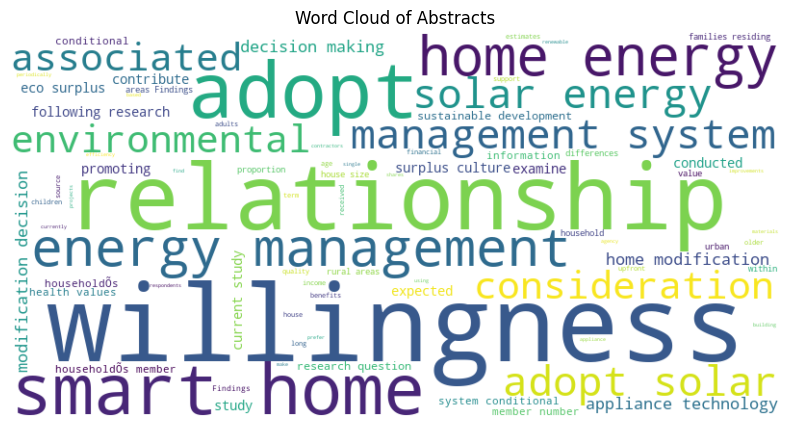

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all abstracts into a single string
text = ' '.join(df['abstract'].dropna().tolist())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Abstracts')
plt.show()

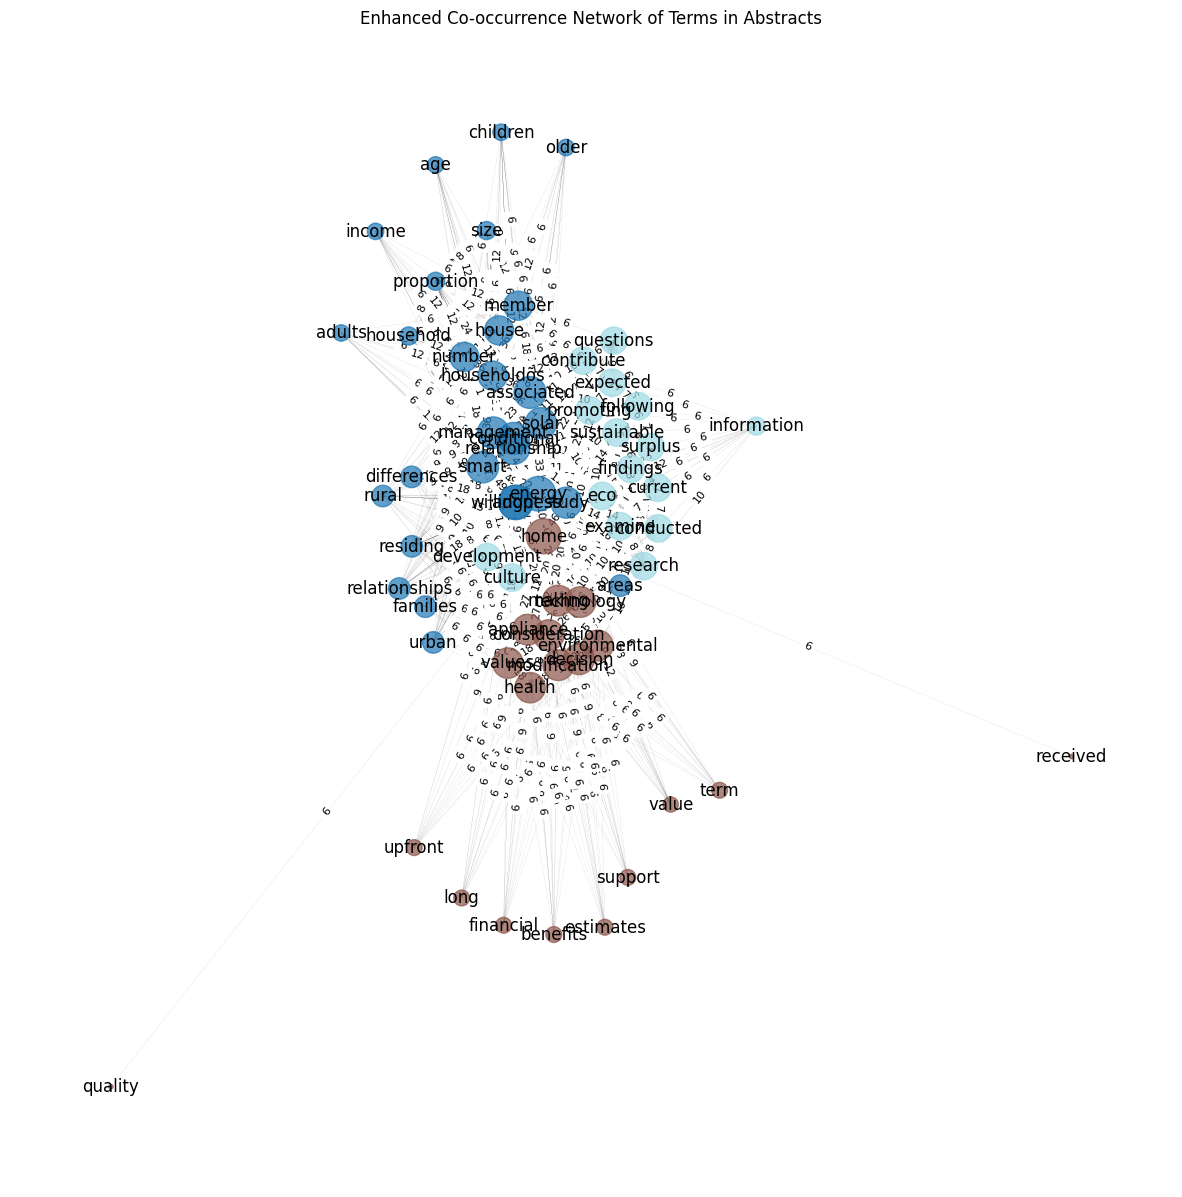

In [5]:
import networkx as nx
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt
from networkx.algorithms import community

# Tokenize and create a co-occurrence matrix
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['abstract'].dropna())
Xc = (X.T * X)  # Co-occurrence matrix
Xc.setdiag(0)  # Set diagonal to zero

# Create graph from co-occurrence matrix
G = nx.from_scipy_sparse_array(Xc)

# Map indices to words
terms = vectorizer.get_feature_names_out()
mapping = {i: terms[i] for i in range(len(terms))}
G = nx.relabel_nodes(G, mapping)

# Filter edges by weight (co-occurrence count)
threshold = 5  # Adjust this threshold based on your dataset
edges = [(u, v, d) for u, v, d in G.edges(data=True) if d['weight'] > threshold]
H = nx.Graph()
H.add_edges_from(edges)

# Compute node degrees
degrees = dict(H.degree())

# Detect communities
communities = community.greedy_modularity_communities(H)
community_map = {}
for i, com in enumerate(communities):
    for name in com:
        community_map[name] = i

# Assign colors to communities
colors = [community_map[node] for node in H.nodes()]

# Draw the network
plt.figure(figsize=(15, 15))
pos = nx.spring_layout(H, k=0.15, seed=42)  # Seed for reproducibility

# Draw nodes with sizes proportional to degree
nx.draw_networkx_nodes(H, pos,
                       node_size=[degrees[node] * 10 for node in H.nodes()],
                       node_color=colors,
                       cmap=plt.cm.tab20,
                       alpha=0.7)

# Draw edges with widths proportional to weight
nx.draw_networkx_edges(H, pos,
                       width=[d['weight'] * 0.01 for (u, v, d) in H.edges(data=True)],
                       alpha=0.5)

# Draw node labels
nx.draw_networkx_labels(H, pos, font_size=12, font_color='black')

# Draw edge labels
edge_labels = {(u, v): d['weight'] for u, v, d in H.edges(data=True)}
nx.draw_networkx_edge_labels(H, pos, edge_labels=edge_labels, font_size=8)

plt.title('Enhanced Co-occurrence Network of Terms in Abstracts')
plt.axis('off')
plt.show()

2025-09-22 10:01:36,107 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|████████████████████████████████████| 1/1 [00:00<00:00,  1.58it/s]
2025-09-22 10:01:36,755 - BERTopic - Embedding - Completed ✓
2025-09-22 10:01:36,756 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-09-22 10:01:36,848 - BERTopic - Dimensionality - Completed ✓
2025-09-22 10:01:36,850 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-09-22 10:01:36,868 - BERTopic - Cluster - Completed ✓
2025-09-22 10:01:36,896 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-09-22 10:01:36,952 - BERTopic - Representation - Completed ✓


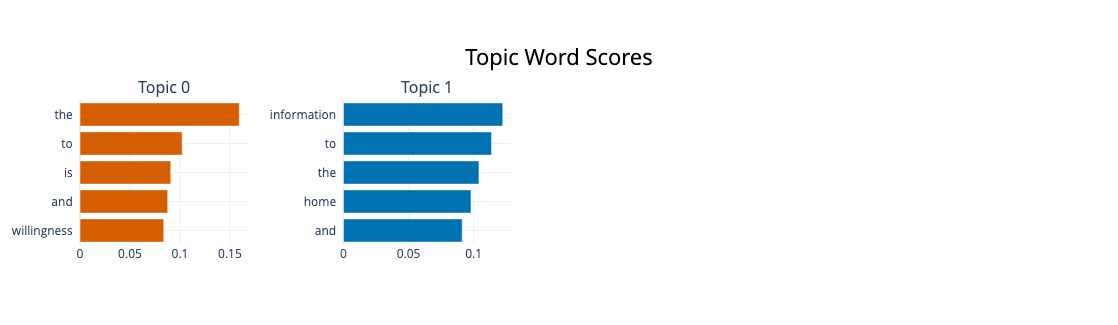

In [7]:
# --- Step 2: Topic Modeling with BERTopic ---
docs = df['abstract'].fillna("").tolist()
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
topic_model = BERTopic(
    embedding_model=embedding_model,
    calculate_probabilities=False,
    verbose=True,
    min_topic_size=2
)
topics, probs = topic_model.fit_transform(docs)

# Visualize top topics
topic_model.visualize_barchart()

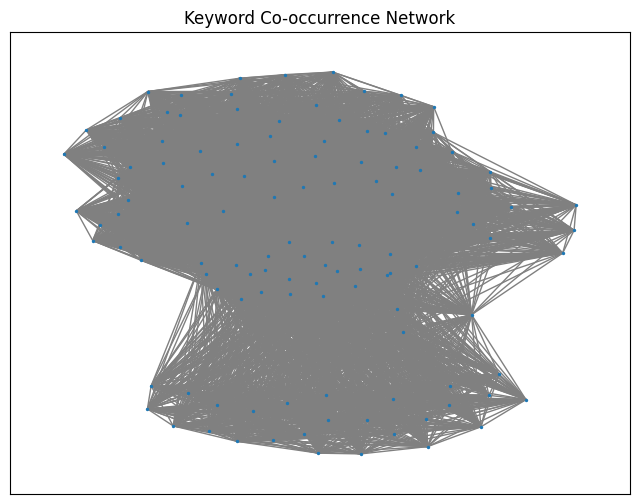

In [9]:
# --- Step 3: Build simple citation keyword co-occurrence network ---
# Tokenize keywords in abstracts
keywords = df['abstract'].str.lower().str.split()
G = nx.Graph()

for idx, row in df.iterrows():
    words = set(row['abstract'].split())
    for w1 in words:
        for w2 in words:
            if w1 != w2:
                G.add_edge(w1, w2)

plt.figure(figsize=(8,6))
nx.draw_networkx(G, with_labels=False, node_size=2, edge_color="gray")
plt.title("Keyword Co-occurrence Network")
plt.show()

In [10]:
# --- Step 4: Save processed outputs ---
df.to_csv("citing_papers.csv", index=False)
topic_model.save("bertopic_model")

2025-09-22 10:03:21,188 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
